In [24]:
# Loading the required datasets 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the datasest

In [10]:
M_food_prices = pd.read_csv("wfp_market_food_prices.csv", on_bad_lines='error')

In [26]:
M_food_prices.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,612035.000000,612035.000000,612035.000000,612035.000000,612035.000000,612034.000000,612034.000000,612034.000000,612034.000000,6.120340e+05
mean,142.686428,11254.992749,849.863812,158.700132,54.460397,14.927718,9.690055,6.396525,2012.312955,3.811781e+03
std,56.403162,18634.362224,494.039910,119.280848,21.693574,0.286900,11.197979,3.436530,3.677556,5.999491e+04
min,1.000000,0.000000,101.000000,50.000000,23.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,108.000000,1497.000000,422.000000,67.000000,28.000000,15.000000,5.000000,3.000000,2011.000000,5.778000e+01
50%,152.000000,1934.000000,892.000000,101.000000,61.000000,15.000000,5.000000,6.000000,2013.000000,2.060000e+02
75%,196.000000,21969.000000,1087.000000,227.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,6.000000e+02
max,238.000000,112869.000000,2094.000000,490.000000,95.000000,18.000000,97.000000,12.000000,2017.000000,5.833333e+06


In [16]:
# Changing the column name to something more meaningful

M_food_prices.rename(columns={
    'adm0_id': 'country_id',
    'adm0_name': 'country_name',
    'adm1_id': 'region_id',
    'adm1_name': 'region_name',
    'mkt_id': 'market_id',
    'cm_id': 'commodity_id',
    'cur_id': 'currency_id',
    'pt_id': 'price_type_id',
    'um_id': 'unit_measure_id',
    'mp_month': 'price_month',
    'mp_year': 'price_year',
    'mp_price': 'price'
}, inplace=True)



## Filtering Dataset for my data

In [17]:
M_food_prices = M_food_prices[M_food_prices['country_name'].isin(['India', 'Pakistan', 'Sri Lanka', 'Nepal', 'Bhutan', 'Bangladesh'])]


## Identifying any missing values in the data set

In [18]:

missing_values = M_food_prices.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 country_id               0
country_name             0
region_id                0
region_name           2716
market_id                0
mkt_name                 0
commodity_id             0
cm_name                  0
currency_id              0
cur_name                 0
price_type_id            0
pt_name                  0
unit_measure_id          0
um_name                  0
price_month              0
price_year               0
price                    0
mp_commoditysource       0
dtype: int64


## Removing any duplicate entries in the data

In [20]:
M_food_prices_cleaned = M_food_prices.drop_duplicates()

## Summary of duplicate entries vs original data
No duplicate values were found in the dataset

In [25]:
print(len(M_food_prices_cleaned))
print(len(M_food_prices))
M_food_prices_cleaned.head(5)

83569
83569


,country_id,country_name,region_id,region_name,market_id,mkt_name,commodity_id,cm_name,currency_id,cur_name,price_type_id,pt_name,unit_measure_id,um_name,price_month,price_year,price,mp_commoditysource
12663,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,12.0,2006.0,23.0,Website of Department of Agricultural Marketing
12664,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,1.0,2007.0,25.5,Website of Department of Agricultural Marketing
12665,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,2.0,2007.0,25.5,Website of Department of Agricultural Marketing
12666,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,3.0,2007.0,26.0,Website of Department of Agricultural Marketing
12667,23,Bangladesh,575,Barisal,112,Barisal Division,58,Wheat flour,25,BDT,15.0,Retail,5.0,KG,4.0,2007.0,26.0,Website of Department of Agricultural Marketing


# Visualizations

C:\Users\raghu\AppData\Local\Temp\ipykernel_34724\1686976185.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price_month', y='price', data=month_avg_price, palette='viridis')


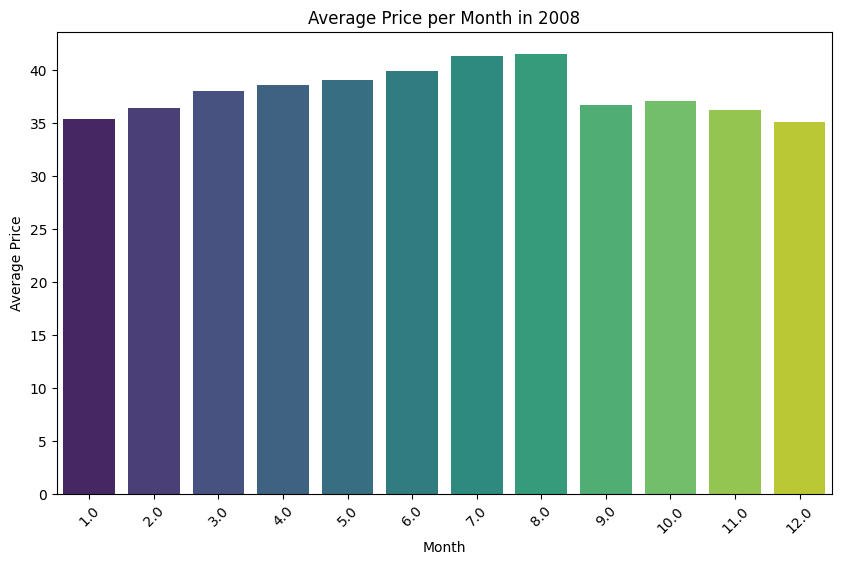

In [46]:

year_to_analyze = 2008

# Filter the data for the specified year
year_data = M_food_prices_cleaned[M_food_prices_cleaned['price_year'] == year_to_analyze]

# Group by month and calculate the average price
month_avg_price = year_data.groupby('price_month')['price'].mean().reset_index()


plt.figure(figsize=(10, 6))
sns.barplot(x='price_month', y='price', data=month_avg_price, palette='viridis')
plt.title(f'Average Price per Month in {year_to_analyze}')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()